In [16]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ["dislike", "fist", "like", "ok", "one", "peace", "rock", "stop", "three", "two_up"]

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

PATH = '../gesture_dataset_sample'

## helper function to load and parse annotations

In [17]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [18]:
# pretty-print first element
#000484ab-5fd0-49b8-9253-23a22b71d7b1
print(json.dumps(annotations['like']['0014182f-d756-42b3-896c-c52de76926bb'], indent=2))

{
  "bboxes": [
    [
      0.38056273,
      0.35650891,
      0.17322347,
      0.10461114
    ]
  ],
  "labels": [
    "like"
  ],
  "landmarks": [
    [
      [
        0.5497169170918876,
        0.4276043615779976
      ],
      [
        0.5218336293004483,
        0.40536586667786917
      ],
      [
        0.48288133220125257,
        0.3930262243722419
      ],
      [
        0.4501841862302019,
        0.37981099195030416
      ],
      [
        0.44251365410099686,
        0.36620499322043343
      ],
      [
        0.43138297470865106,
        0.406093902776592
      ],
      [
        0.4072660997339628,
        0.4073950234480344
      ],
      [
        0.42588200316326846,
        0.40612291879594015
      ],
      [
        0.4441470003072778,
        0.4049221293588555
      ],
      [
        0.4314493576491367,
        0.4212979654419442
      ],
      [
        0.42096276272263283,
        0.4180224457320293
      ],
      [
        0.43966095717106257,
      

## helper function to pre-process images (color channel conversion and resizing)

In [19]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [20]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

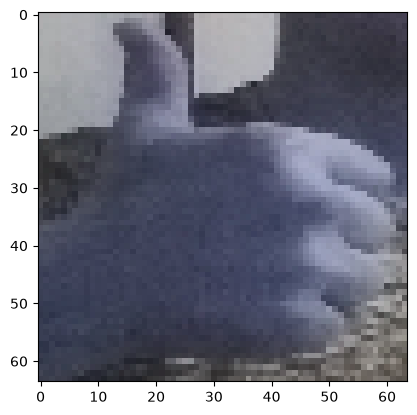

In [21]:
plt.imshow(random.sample(images, 1)[0])
#plt.imshow(random.sample(images, 1)[0], cmap='gray')

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

2586
647
2586
647


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [23]:
# Convert to float
X_train = np.array(X_train).astype('float32')
# Normalization [0,1]
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.


# Convert interger class labels in to one hot vector
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# rename for demonstration purposes
train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(2586, 64, 64, 3) (647, 64, 64, 3) (2586, 11) (647, 11)


In [24]:
# variables for hyperparameters
batch_size = 8 
epochs = 50 
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# Randomly disables 20% of neurons during each training step
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs

# If validation loss stops improving for 2 epochs, multiply  the learning rate by 0.2 (slow down/fine tune)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
# if validation loss doesn't improve for 3 epchs, stop training entierly
stop_early = EarlyStopping(monitor='val_loss', patience=3)

## now, we can train the model using the fit() function
## this will take a while

In [25]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
324/324 [==============================] - 3s 5ms/step - loss: 2.3541 - accuracy: 0.2119 - val_loss: 2.2356 - val_accuracy: 0.2457 - lr: 0.0010
Epoch 2/50
324/324 [==============================] - 2s 5ms/step - loss: 2.1181 - accuracy: 0.2672 - val_loss: 1.8509 - val_accuracy: 0.3447 - lr: 0.0010
Epoch 3/50
324/324 [==============================] - 2s 5ms/step - loss: 1.8170 - accuracy: 0.3589 - val_loss: 1.6268 - val_accuracy: 0.4189 - lr: 0.0010
Epoch 4/50
324/324 [==============================] - 2s 5ms/step - loss: 1.5329 - accuracy: 0.4578 - val_loss: 1.3224 - val_accuracy: 0.5394 - lr: 0.0010
Epoch 5/50
324/324 [==============================] - 2s 5ms/step - loss: 1.2105 - accuracy: 0.5893 - val_loss: 1.0851 - val_accuracy: 0.6182 - lr: 0.0010
Epoch 6/50
324/324 [==============================] - 2s 5ms/step - loss: 1.0118 - accuracy: 0.6516 - val_loss: 0.9901 - val_accuracy: 0.6553 - lr: 0.0010
Epoch 7/50
324/324 [==============================] - 2s 5ms/step - lo

# read in images and annotations from myself and tutors

In [26]:
tutor_path = "tutor_images"
jonas_path = "jonas_images"

all_annotations = {}
custom_images = []

# load annotations from both folders and combine them into one dict
with open(f"{tutor_path}/annot-tutors.json", "r") as f:
    tutor_ann = json.load(f)

with open(f"{jonas_path}/annot-jonas.json", "r") as f:
    jonas_ann = json.load(f)

# combine annotations
for uid, ann in tutor_ann.items():
    all_annotations[uid] = {
        "source": "tutor",
        "annotation": ann
    }
    
for uid, ann in jonas_ann.items():
    if uid in all_annotations:
        print(f"Warning: duplicate UID found: {uid} (overwriting tutor with jonas)")
    all_annotations[uid] = {
        "source": "jonas",
        "annotation": ann
    }

# load images from both folders and store them in a list along with their filename
for filename in os.listdir(tutor_path):
    if filename.endswith(".json"):
        continue
    img = cv2.imread(f"{tutor_path}/{filename}")
    custom_images.append((filename, img))

for filename in os.listdir(jonas_path):
    if filename.endswith(".json"):
        continue
    img = cv2.imread(f"{jonas_path}/{filename}")
    custom_images.append((filename, img))

print(len(all_annotations))
print(len(custom_images))

9
9


## crop and preprocess custom images

In [27]:
class_names = label_names.copy()

processed_custom_images = []
processed_custom_labels = []
processed_label_names = []

# loop over custom images
for filename, image in custom_images:
    
    # extract UID from filename and get corresponding annotation
    uid = filename.split(".")[0]
    item = all_annotations.get(uid)

    # if there is no annotation for this image, print a warning and skip it
    if item is None:
        print(f"No annotation found for {filename} (UID: {uid})")
        continue

    annotation = item["annotation"]

    # iterate over all hands annotated in the image
    for i, bbox in enumerate(annotation["bboxes"]):
        x1 = int(bbox[0] * image.shape[1])
        y1 = int(bbox[1] * image.shape[0])
        w = int(bbox[2] * image.shape[1])
        h = int(bbox[3] * image.shape[0])
        x2 = x1 + w
        y2 = y1 + h

        # crop and preprocess the image
        crop = image[y1:y2, x1:x2]
        preprocessed = preprocess_image(crop)

        # get the annotated hand's label
        label = annotation["labels"][i]
        label_index = class_names.index(label)

        # store preprocessed image and label in corresponding lists
        processed_custom_images.append(preprocessed)
        processed_custom_labels.append(label_index)
        processed_label_names.append(label)
        


    

## take a look at one custom image

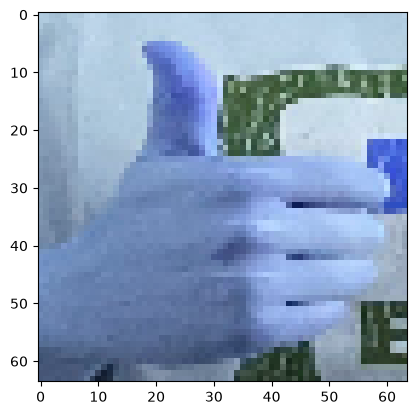

In [28]:
plt.imshow(random.sample(processed_custom_images, 1)[0])

## make predictions for custom images

In [29]:
gold_labels = []
predicted_labels = []

# make predictions on custom images and compare them to the actual labels
for img, label_index, actual_name in zip(processed_custom_images, processed_custom_labels, processed_label_names):
    # preprocess image and prepare it for prediction
    img_input = img.reshape(1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS).astype("float32") / 255.0
    prediction = model.predict(img_input, verbose=0)
    predicted_label_index = np.argmax(prediction)
    prediction_class = class_names[predicted_label_index]
    
    # store gold and predicted labels for confusion matrix
    gold_labels.append(label_index)
    predicted_labels.append(predicted_label_index)

    print("Predicted class:", prediction_class)
    print("Actual class:", actual_name)

Predicted class: rock
Actual class: rock
Predicted class: rock
Actual class: rock
Predicted class: no_gesture
Actual class: no_gesture
Predicted class: peace
Actual class: peace
Predicted class: no_gesture
Actual class: no_gesture
Predicted class: peace
Actual class: peace
Predicted class: no_gesture
Actual class: no_gesture
Predicted class: like
Actual class: like
Predicted class: no_gesture
Actual class: no_gesture
Predicted class: like
Actual class: like
Predicted class: no_gesture
Actual class: no_gesture
Predicted class: like
Actual class: like
Predicted class: ok
Actual class: rock
Predicted class: no_gesture
Actual class: peace


## plot and safe confusion matrix

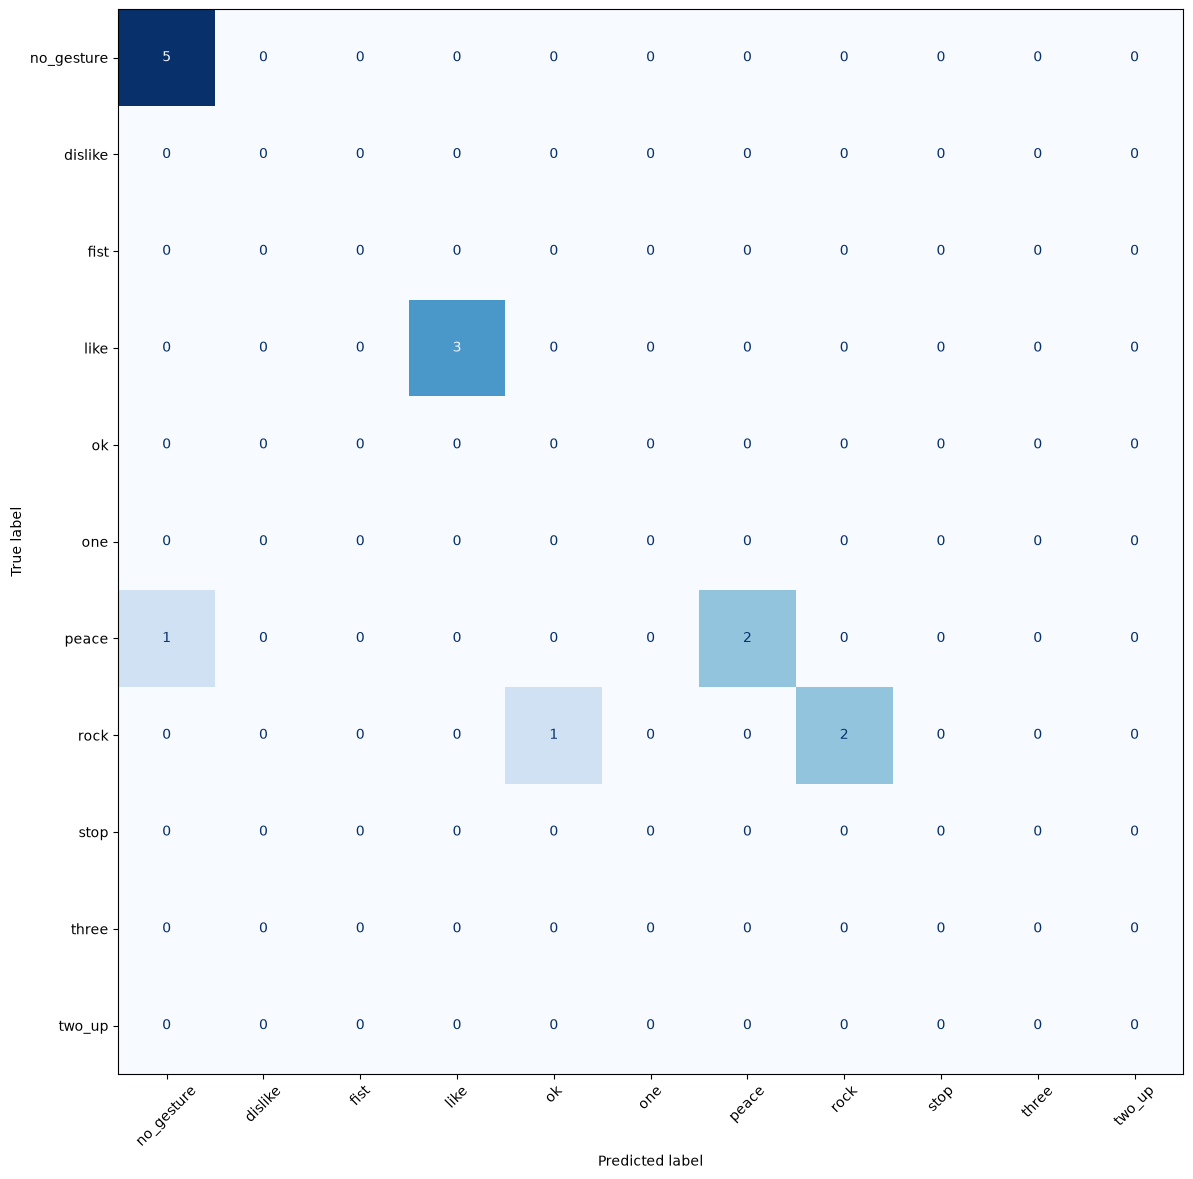

<Figure size 640x480 with 0 Axes>

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

all_class_ids = np.arange(len(class_names))

matrix = confusion_matrix(gold_labels, predicted_labels, labels=all_class_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()

plt.savefig("conf-matrix.png", dpi=300, bbox_inches="tight")